In [32]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782641936.log")
assert p.exists()

In [41]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

4049


In [42]:
def extract_animal_data(line):
    # Match new log format: [unix_ts=...] [frame=...] animal_despawn reason=... lifetime_frames=... animal=Animal { ... }
    pat = (
        r".*"
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_timestamp>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"animal_despawn "
        r"reason=(?P<reason>\w+) "
        r"lifetime_frames=(?P<lifetime>\d+) "
        r"animal=Animal\s*\{ "
        r"id:\s*(?P<id>\d+),\s*"
        r"parent_id:\s*Some\((?P<parent_id>\d+|None)\),\s*"
        r"diet:\s*(?P<diet>\w+),\s*"
        r".*"
        r"family:\s*(?P<family>\d+)\s*\}"
        r".*"
    )

    m = re.match(
        pat,
        line,
    )

    if m is not None:
        d = {}
        d["simulation_start_ts"] = m.group("simulation_start_ts")
        d["unix_timestamp"] = float(m.group("unix_timestamp"))
        d["lifetime"] = float(m.group("lifetime"))
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        d["id"] = int(m.group("id"))
        d["parent_id"] = m.group("parent_id")
        return d
    return None


In [43]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [44]:
df

,simulation_start_ts,unix_timestamp,lifetime,diet,family,id,parent_id
0,1782641936,1.782642e+09,109.0,Omnivore,1937955268,18126405915448963616,15596494880715443254
1,1782641936,1.782642e+09,15.0,Omnivore,1937955268,11566586727765185626,13181906452373553798
2,1782641936,1.782642e+09,33.0,Omnivore,1937955268,5891330530779113208,13181906452373553798
3,1782641936,1.782642e+09,17.0,Omnivore,1937955268,4308020478633090931,15596494880715443254
4,1782641936,1.782642e+09,370.0,Omnivore,1937955268,16976466600690873180,15596494880715443254
...,...,...,...,...,...,...,...
535,1782641936,1.782642e+09,541.0,Herbivore,1872833297,590228307299794029,13062314536447422980
536,1782641936,1.782642e+09,3076.0,Herbivore,1872833297,13016481643457752805,649906616048221556
537,1782641936,1.782642e+09,2905.0,Herbivore,1872833297,193883361901473656,2200132265029326812
538,1782641936,1.782642e+09,476.0,Herbivore,1872833297,17018091479858496814,7231197489507594179


<Axes: xlabel='diet', ylabel='lifetime'>

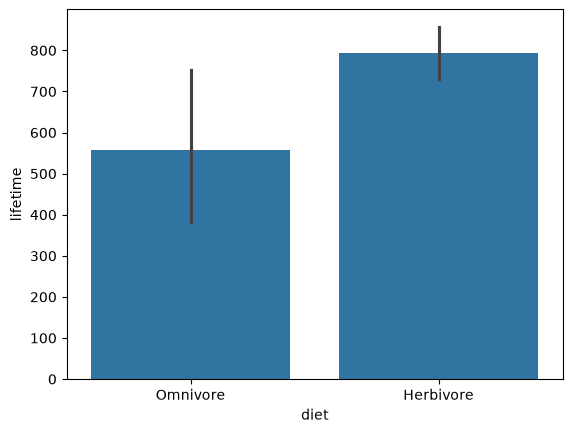

In [45]:
sns.barplot(data=df, x="diet", y="lifetime")

In [46]:
df[§]

SyntaxError: invalid character '§' (U+00A7) (2237816332.py, line 1)

# Population

In [47]:
def extract_population_data(line):
    line = re.sub(
        r"animals=\{carnivores:(\d+)\s+herbivores:(\d+)\s+omnivores:(\d+)\}",
        r'animals={"carnivores":\1,"herbivores":\2,"omnivores":\3}',
        line,
    )
    m = re.match(
        r".*frame=(?P<frame>\d+).*population_size plants=(?P<n_plants>\d+)\s+animals=(?P<json>\{.*?\})\s+families=(?P<families>\d+:\d+(?:\|\d+:\d+)*).*",
        line,
    )
    if m is not None:
        d = {}
        d["frame"] = int(m.group("frame"))
        d["n_plants"] = int(m.group("n_plants"))
        json_data = json.loads(m.group("json"))
        d["carnivores"] = int(json_data.get("carnivores", 0))
        d["herbivores"] = int(json_data.get("herbivores", 0))
        d["omnivores"] = int(json_data.get("omnivores", 0))
        d["families"] = m.group("families")
        return d
    return m     

In [48]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,n_plants,carnivores,herbivores,omnivores,families
frame,,,,,
227,11,1,0,0,0:1
253,12,1,0,0,0:1
254,13,1,0,0,0:1
260,14,1,0,0,0:1
263,15,1,0,0,0:1
...,...,...,...,...,...
7983,11,0,36,17,1872833297:36|1937955268:16|3384407461:1
7993,10,0,36,17,1872833297:36|1937955268:16|3384407461:1
8001,10,0,35,17,1872833297:35|1937955268:16|3384407461:1


### Genetic DIversity

In [49]:

df["families"] = df["families"].str.split("|").apply(lambda x: [tuple(map(int, f.split(":"))) for f in x])

<Axes: xlabel='frame'>

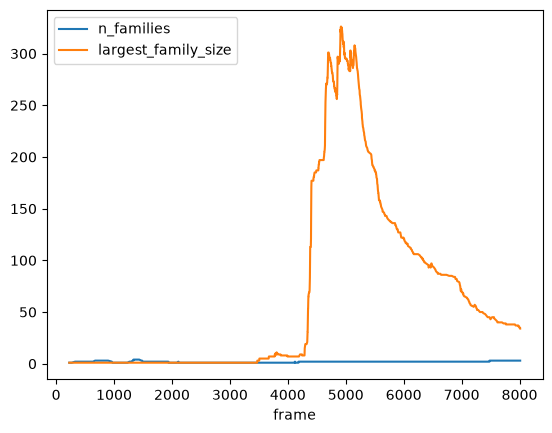

In [50]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

### Population

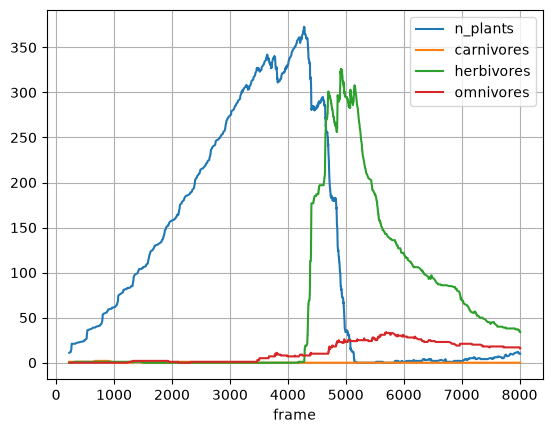

In [51]:
#df["n_plants"].plot()
df.plot()
plt.grid()
plt.legend()